In [1]:
from qiskit import *

# Definitions of the carry, carry inverse, and sum gates
#Carry converted to a custom gate
car = QuantumCircuit(4, name = 'Carry')
car.ccx(1,2,3)
car.cx(1,2)
car.ccx(0,2,3)
carry_gate = car.to_gate()

In [3]:
#Carry Inverse converted to a custom gate
carry_inv = QuantumCircuit(4, name = 'Carry Inverse')
carry_inv.ccx(0,2,3)
carry_inv.cx(1,2)
carry_inv.ccx(1,2,3)
car_inv_gate = carry_inv.to_gate()

In [4]:
#Sum converted to a custom gate
sum = QuantumCircuit(3, name = 'Sum')
sum.cx(1,2)
sum.cx(0,2)
sum_gate = sum.to_gate()

In [5]:
# Definition of the Addition Gate
def create_add_gate(n:int):
    A = QuantumRegister(n,"a")
    B = QuantumRegister(n + 1,"b")
    C = QuantumRegister(n,"c")
    
    add = QuantumCircuit(A,B,C, name= 'Add')

    # Subcircuit U_1 with a cascade of carry gates
    for qubit in range(n - 1):
        add.append(carry_gate,[C[qubit], A[qubit], B[qubit], C[qubit + 1]])

    # Subcircuit U_2
    add.append(carry_gate,[C[n-1], A[n-1],B[n-1],B[n]])
    add.cx(A[n-1], B[n-1])
    add.append(sum_gate,[C[n-1], A[n-1], B[n-1]])

    # Subcircuit U_3 with a cascade of sums and carry inverses
    for qubit in range(n - 1)[::-1]:
        add.append(car_inv_gate,[C[qubit],A[qubit],B[qubit],C[qubit+1]])
        add.append(sum_gate,[C[qubit], A[qubit], B[qubit]])
        
    return add.to_gate()

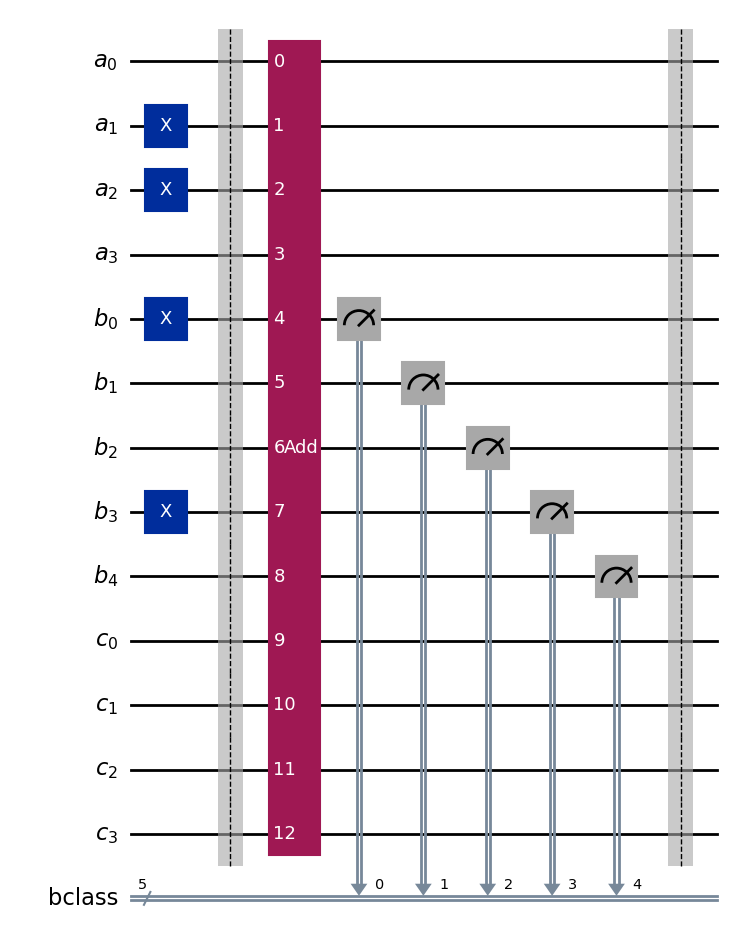

In [6]:
# Create an Add gate with n = 4 bits
n = 4
A = QuantumRegister(n,"a")
B = QuantumRegister(n + 1,"b")
C = QuantumRegister(n,"c")
B_C = ClassicalRegister(n + 1,"bclass") #measurement for output
#C_C = ClassicalRegister(n,"cclass") #measurement for Carry

seed_a = '0110' # Value (6) to store in register a
seed_b = '01001' # Value (9) to store in register b
                # Expected sum: 15 = |01111>

AddCirc = QuantumCircuit(A,B,C,B_C)

seed_a = list(map(int, list(seed_a)))[::-1] # Rearrange the initial values in reverse order according to Qiskit convention

# encode the value of register a
for bit in range(len(seed_a)):
    if seed_a[bit] == 1:
        AddCirc.x(A[bit])
        
# Repeat the process for the initial value of register b
seed_b = list(map(int, list(seed_b)))[::-1] 

# encode the value of register b
for bit in range(len(seed_b)):
    if seed_b[bit] == 1:
        AddCirc.x(B[bit])

AddCirc.barrier()

# Create the Add gate:
AddGate = create_add_gate(n)
AddCirc.append(AddGate,A[:]+B[:]+C[:])

# Get the state of the data qubits.
AddCirc.measure(B, B_C)
#AddCirc.measure(C, C_C)
AddCirc.barrier()

#draw the circuit.
AddCirc.draw(output="mpl")

In [7]:
# Measure the value of the carry register in the n most significant qubits
# and the value of the register b in the n + 1 least significant qubits
from qiskit_aer.primitives import SamplerV2
 
sampler = SamplerV2()
job_simulator = sampler.run([AddCirc.decompose(reps=6)], shots = 1024)

result_simulator = job_simulator.result()
counts = result_simulator[0].data.bclass.get_counts() #data."measure label"
#counts2 = result_simulator[0].data.cclass.get_counts()
print(counts)

{'01111': 1024}


In [8]:
from qiskit_aer import AerProvider, AerSimulator, QasmSimulator, StatevectorSimulator, UnitarySimulator
from qiskit.visualization import *
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler, Estimator, Session, Options

#Load your IBM Quantum account(s)
service = QiskitRuntimeService(channel = "ibm_cloud")

In [9]:
backend = service.least_busy(simulator = False, operational = True)
print(backend)

<IBMBackend('ibm_fez')>


In [10]:
# Import the NoiseModel
from qiskit_aer.noise import NoiseModel

# Create the noise model based on the backend properties
noise_model = NoiseModel.from_backend(backend)
# Get coupling map from backend
coupling_map = backend.configuration().coupling_map
# Get basis gates from noise model
basis_gates = noise_model.basis_gates
# Get the Aer simulator to apply noise model
noisy_simulator = AerSimulator()

opt_level = 3
pass_manager = generate_preset_pass_manager(backend = noisy_simulator, optimization_level = opt_level)
isa_circuit = pass_manager.run(AddCirc)

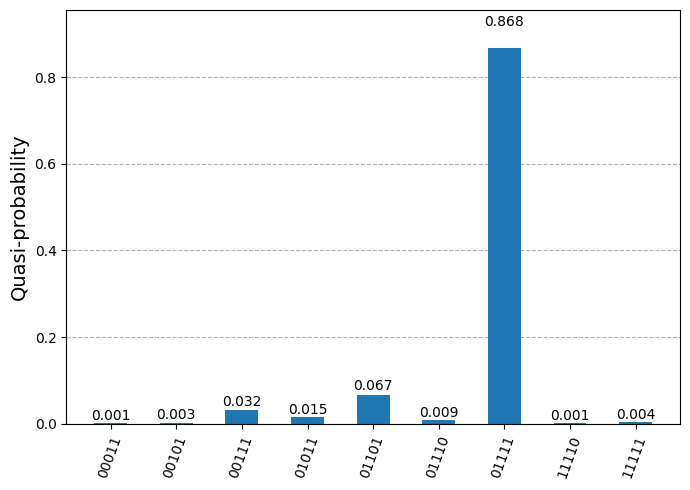

In [11]:
# Execute the circuit on the simulator with the backend properties, and generated noise model
result = noisy_simulator.run(isa_circuit, coupling_map = coupling_map, basis_gates = basis_gates, noise_model = noise_model).result()
# Obtain and print results
counts = result.get_counts()
plot_distribution(counts)

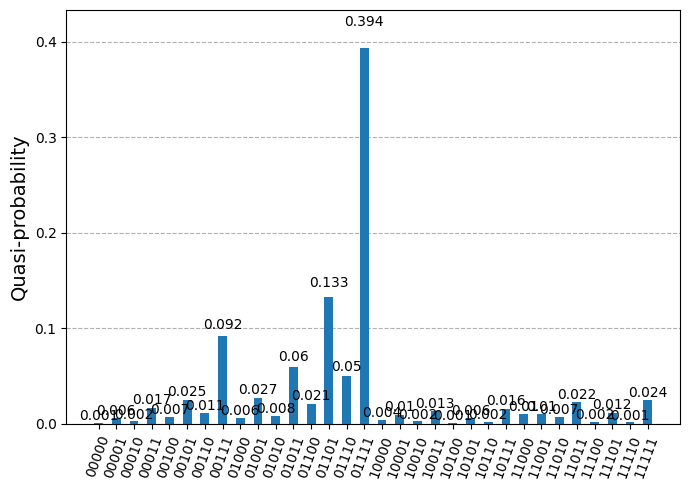

In [12]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

opt_level = 3
pass_manager = generate_preset_pass_manager(backend = backend, optimization_level = opt_level)
isa_circuit = pass_manager.run(AddCirc)

sampler = Sampler(mode = backend)

result = sampler.run([isa_circuit]).result()

# Get results for the first (and only) PUB
pub_result = result[0]
counts = pub_result.data.bclass.get_counts()
plot_distribution(counts)

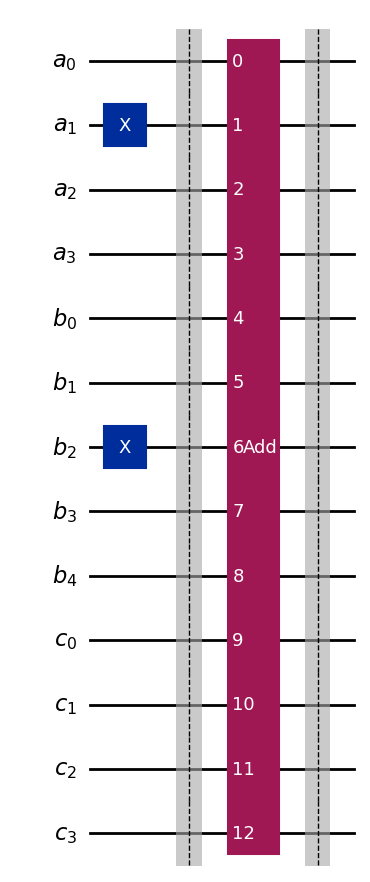

In [26]:
# Create an Add gate with n = 4 bits, no measurements
n = 4
A = QuantumRegister(n,"a")
B = QuantumRegister(n + 1,"b")
C = QuantumRegister(n,"c")
#B_C = ClassicalRegister(n + 1,"bclass") #measurement for output
#C_C = ClassicalRegister(n,"cclass") #measurement for Carry

seed_a = '0010' # Value (2) to store in register a
seed_b = '00100' # Value (4) to store in register b
                # Expected sum: 6 = |01100>

AddCirc = QuantumCircuit(A,B,C)

seed_a = list(map(int, list(seed_a)))[::-1] # Rearrange the initial values in reverse order according to Qiskit convention

# encode the value of register a
for bit in range(len(seed_a)):
    if seed_a[bit] == 1:
        AddCirc.x(A[bit])
        
# Repeat the process for the initial value of register b
seed_b = list(map(int, list(seed_b)))[::-1] 

# encode the value of register b
for bit in range(len(seed_b)):
    if seed_b[bit] == 1:
        AddCirc.x(B[bit])

AddCirc.barrier()

# Create the Add gate:
AddGate = create_add_gate(n)
AddCirc.append(AddGate,A[:]+B[:]+C[:])

# Get the state of the data qubits.
#AddCirc.measure(B, B_C)
#AddCirc.measure(C, C_C)
AddCirc.barrier()

#draw the circuit.
AddCirc.draw(output="mpl")

In [27]:
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler, Session, Options, EstimatorV2 as Estimator
from qiskit.quantum_info import SparsePauliOp, SparseObservable

#Load your IBM Quantum account(s)
service = QiskitRuntimeService(channel = "ibm_cloud")
backend = service.least_busy(operational=True, simulator=False)

In [28]:
total_qubits = len(A)+len(B)+len(C) 

observable = SparsePauliOp.from_sparse_list([
    ("I", [0], 15.5),
    ("Z", [4], -0.5),
    ("Z", [5], -1),
    ("Z", [6], -2),
    ("Z", [7], -4),
    ("Z", [8], -8),
], num_qubits=total_qubits)

print(observable)

SparsePauliOp(['IIIIIIIIIIIII', 'IIIIIIIIZIIII', 'IIIIIIIZIIIII', 'IIIIIIZIIIIII', 'IIIIIZIIIIIII', 'IIIIZIIIIIIII'],
              coeffs=[15.5+0.j, -0.5+0.j, -1. +0.j, -2. +0.j, -4. +0.j, -8. +0.j])


In [29]:
# Convert to an ISA circuit and layout-mapped observables.
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
isa_circuit = pm.run(AddCirc)
 
isa_circuit.draw("mpl", idle_wires=False)
mapped_observable = observable.apply_layout(isa_circuit.layout)

In [30]:
# Construct the Estimator instance.
 
estimator = Estimator(mode=backend)
estimator.options.resilience_level = 2
estimator.options.default_shots = 5000
 
# One pub, with one circuit to run against five different observables.
job = estimator.run([(isa_circuit, mapped_observable)])
 
# Use the job ID to retrieve your job data later
print(f">>> Job ID: {job.job_id()}")

>>> Job ID: d71tq01amkec73a0fse0


In [31]:
# This is the result of the entire submission.  You submitted one Pub,
# so this contains one inner result (and some metadata of its own).
job_result = job.result()
 
# This is the result from our single pub, which had six observables,
# so contains information on all six.
pub_result = job.result()[0]
print(pub_result)

PubResult(data=DataBin(evs=np.ndarray(<shape=(), dtype=float64>), stds=np.ndarray(<shape=(), dtype=float64>), evs_noise_factors=np.ndarray(<shape=(3,), dtype=float64>), stds_noise_factors=np.ndarray(<shape=(3,), dtype=float64>), ensemble_stds_noise_factors=np.ndarray(<shape=(3,), dtype=float64>), evs_extrapolated=np.ndarray(<shape=(2, 4), dtype=float64>), stds_extrapolated=np.ndarray(<shape=(2, 4), dtype=float64>)), metadata={'shots': 5024, 'target_precision': 0.01414213562373095, 'circuit_metadata': {}, 'resilience': {'zne': {'extrapolator': 'multiple'}}, 'num_randomizations': 32})


In [32]:
print(f"Expectation value: {pub_result.data.evs}")

Expectation value: 9.761261215155406


In [33]:
# Instantiate the QASM simulator from the Aer provider
backend_simulator = QasmSimulator()

In [34]:
# Transpile the circuit
transpiled_qc = transpile(AddCirc, backend_simulator)
mapped_observable = observable.apply_layout(transpiled_qc.layout)

In [35]:
# Construct the Estimator instance.
 
estimator = Estimator(mode=backend_simulator)
#estimator.options.resilience_level = 2
estimator.options.default_shots = 5000
 
# One pub, with one circuit to run against five different observables.
job = estimator.run([(transpiled_qc, mapped_observable)])
 
# Use the job ID to retrieve your job data later
print(f">>> Job ID: {job.job_id()}")

>>> Job ID: 94dcc452-d369-440a-8e7e-e53ad923f9be


In [36]:
# This is the result of the entire submission.  You submitted one Pub,
# so this contains one inner result (and some metadata of its own).
job_result = job.result()
 
# This is the result from our single pub, which had six observables,
# so contains information on all six.
pub_result = job.result()[0]
print(pub_result)

PubResult(data=DataBin(evs=np.ndarray(<shape=(), dtype=float64>), stds=np.float64(0.0)), metadata={'target_precision': 0.01414213562373095, 'shots': 5000, 'circuit_metadata': {}})


In [37]:
print(f"Expectation value: {pub_result.data.evs}")

Expectation value: 6.0
